# GROUP ASSIGNMENT – 2026
## Algorithms & Data Structures

| | |
|---|---|
| **Group Members** | Obed Imbahafi : 25094775 & Izabayo Marie Rose:25094930 |


---
<a id='q1'></a>
# Question 1 – Automated Water Billing System

A national water utility replaces manual billing with a computerised system.  
Bills are calculated from units consumed, and an **Environmental Conservation Surcharge (15%)** is added when usage exceeds 20 units.

## (a) Structured English Algorithm

```
BEGIN Water Bill Calculation

  CONSTANTS:
    RATE_PER_UNIT     = 500 RWF per unit
    THRESHOLD         = 20 units
    SURCHARGE_PERCENT = 15 %

  STEP 1: START
  STEP 2: INPUT customer name
  STEP 3: INPUT customer ID
  STEP 4: INPUT units consumed
  STEP 5: CALCULATE base_bill = units × RATE_PER_UNIT
  STEP 6: IF units > THRESHOLD THEN
              excess    = units − THRESHOLD
              surcharge = excess × RATE_PER_UNIT × SURCHARGE_PERCENT
          ELSE
              surcharge = 0
          END IF
  STEP 7: CALCULATE total_bill = base_bill + surcharge
  STEP 8: PRINT billing statement
  STEP 9: STOP

END Water Bill Calculation
```

## (b) Flowchart

```
         [START]
            |
   [Input: Name, ID, Units Consumed]
            |
  [base_bill = units × 500 RWF]
            |
     < units > 20 ? >
    YES /           \ NO
[excess = units−20]  [surcharge = 0]
[surcharge =              |
 excess×500×15%]          |
         \               /
      [total = base_bill + surcharge]
            |
    [Print Billing Statement]
            |
          [STOP]
```
*Diamonds = decisions · Rectangles = processes · Rounded = start/stop*

## (c) Sample Calculations (Manual Trace)

| Customer | Units | Base Bill | Excess Units | Surcharge | Total |
|----------|-------|-----------|--------------|-----------|-------|
| Alice    | 10    | 5,000 RWF | 0            | 0 RWF     | 5,000 RWF |
| Bob      | 20    | 10,000 RWF| 0 (at threshold) | 0 RWF | 10,000 RWF |
| Carol    | 35    | 17,500 RWF| 15           | 15×500×0.15 = 1,125 RWF | 18,625 RWF |

## (d) Python Implementation

In [1]:
# ── Constants ─────────────────────────────────────────────────────────────
RATE_PER_UNIT     = 500    # RWF per unit consumed
THRESHOLD         = 20     # units before surcharge applies
SURCHARGE_PERCENT = 0.15   # 15 %

def calculate_bill(name, customer_id, units):
    """Calculate water bill and return a result dictionary."""
    base_bill = units * RATE_PER_UNIT

    if units > THRESHOLD:
        excess    = units - THRESHOLD
        surcharge = excess * RATE_PER_UNIT * SURCHARGE_PERCENT
    else:
        excess    = 0
        surcharge = 0

    return {
        "name": name, "id": customer_id, "units": units,
        "base": base_bill, "excess": excess,
        "surcharge": surcharge, "total": base_bill + surcharge
    }

def print_water_statement(b):
    """Print a professional billing statement."""
    sep = "=" * 50
    print(sep)
    print("       NATIONAL WATER UTILITY – BILL STATEMENT")
    print(sep)
    print(f"  Customer Name  : {b['name']}")
    print(f"  Customer ID    : {b['id']}")
    print(f"  Units Consumed : {b['units']} units")
    print("-" * 50)
    print(f"  Base Bill      : RWF {b['base']:,.0f}")
    if b['surcharge'] > 0:
        print(f"  Excess Units   : {b['excess']} units")
        print(f"  Eco Surcharge  : RWF {b['surcharge']:,.0f}  (15%)")
    else:
        print("  Eco Surcharge  : RWF 0  (within threshold)")
    print("-" * 50)
    print(f"  TOTAL DUE      : RWF {b['total']:,.0f}")
    print(sep)
    print()

# ── Test with three sample customers ──────────────────────────────────────
customers = [
    ("Alice Uwase",    "CUS-001", 10),
    ("Bob Habimana",   "CUS-002", 20),
    ("Carol Mukamana", "CUS-003", 35),
]

for name, cid, units in customers:
    print_water_statement(calculate_bill(name, cid, units))

       NATIONAL WATER UTILITY – BILL STATEMENT
  Customer Name  : Alice Uwase
  Customer ID    : CUS-001
  Units Consumed : 10 units
--------------------------------------------------
  Base Bill      : RWF 5,000
  Eco Surcharge  : RWF 0  (within threshold)
--------------------------------------------------
  TOTAL DUE      : RWF 5,000

       NATIONAL WATER UTILITY – BILL STATEMENT
  Customer Name  : Bob Habimana
  Customer ID    : CUS-002
  Units Consumed : 20 units
--------------------------------------------------
  Base Bill      : RWF 10,000
  Eco Surcharge  : RWF 0  (within threshold)
--------------------------------------------------
  TOTAL DUE      : RWF 10,000

       NATIONAL WATER UTILITY – BILL STATEMENT
  Customer Name  : Carol Mukamana
  Customer ID    : CUS-003
  Units Consumed : 35 units
--------------------------------------------------
  Base Bill      : RWF 17,500
  Excess Units   : 15 units
  Eco Surcharge  : RWF 1,125  (15%)
--------------------------------------

---
<a id='q2'></a>
# Question 2 – Bank Loan Eligibility System

A commercial bank automates loan eligibility checks using salary, employment status, credit score, and existing debts.

## (a) Role of Algorithms in Banking Information Systems

Algorithms are precise, step-by-step instructions that a computer follows to solve a problem. In banking they are essential because:

1. **Consistency** – Every loan application is judged by exactly the same rules, removing human bias and favouritism.
2. **Speed** – Thousands of applications can be assessed in seconds instead of days.
3. **Accuracy** – Complex calculations (interest rates, risk scores, debt ratios) are done without arithmetic errors.
4. **Fraud Detection** – Algorithms spot unusual patterns in transactions and flag suspicious activity in real time.
5. **Regulatory Compliance** – Banks must follow strict lending laws; algorithms enforce those rules automatically and produce an audit trail.

## (b) Pseudocode Algorithm

```
BEGIN Loan Eligibility Check

  INPUT applicant_name, salary, is_employed, credit_score, existing_debt

  // Rule 1 – Minimum salary
  IF salary < 200,000 THEN
      result = "REJECTED – Salary too low"
      GOTO PRINT_RESULT

  // Rule 2 – Must be employed
  IF is_employed = FALSE THEN
      result = "REJECTED – Applicant not employed"
      GOTO PRINT_RESULT

  // Rule 3 – Minimum credit score
  IF credit_score < 600 THEN
      result = "REJECTED – Poor credit score"
      GOTO PRINT_RESULT

  // Rule 4 – Debt-to-income ratio must be ≤ 40 %
  debt_ratio = existing_debt / salary
  IF debt_ratio > 0.40 THEN
      result = "REJECTED – Debt ratio too high"
      GOTO PRINT_RESULT

  result = "APPROVED"

  PRINT_RESULT:
  PRINT applicant_name, result

END Loan Eligibility Check
```

## (c) Flowchart

```
        [START]
           |
  [Input: Name, Salary, Employed, Credit Score, Existing Debt]
           |
   < Salary >= 200,000? >──NO──► [REJECTED: Salary too low]
           | YES
   < Is Employed? >────────NO──► [REJECTED: Not employed]
           | YES
   < Credit Score >= 600? >─NO──► [REJECTED: Poor credit score]
           | YES
   < Debt/Salary <= 0.40? >─NO──► [REJECTED: Debt ratio too high]
           | YES
       [APPROVED]
           |
      [Print Result]
           |
         [STOP]
```

## (d) Python Implementation

In [2]:
def check_loan_eligibility(name, salary, is_employed, credit_score, existing_debt):
    """Return (name, decision, reason) based on bank eligibility rules."""
    if salary < 200_000:
        return name, "REJECTED", "Salary is below the minimum of RWF 200,000"
    if not is_employed:
        return name, "REJECTED", "Applicant must be currently employed"
    if credit_score < 600:
        return name, "REJECTED", f"Credit score {credit_score} is below minimum of 600"
    debt_ratio = existing_debt / salary
    if debt_ratio > 0.40:
        return name, "REJECTED", f"Debt-to-income ratio {debt_ratio:.0%} exceeds 40%"
    return name, "APPROVED", "All eligibility criteria met"

def print_loan_report(name, decision, reason):
    sep = "=" * 52
    print(sep)
    print("          BANK LOAN ELIGIBILITY REPORT")
    print(sep)
    print(f"  Applicant : {name}")
    print(f"  Decision  : {decision}")
    print(f"  Reason    : {reason}")
    print(sep)
    print()

# ── Test with five different customer profiles ─────────────────────────────
applicants = [
    ("Jean Mugisha",      150_000, True,  680, 40_000),   # Fails: salary
    ("Diane Iradukunda",  300_000, False, 700, 50_000),   # Fails: employment
    ("Eric Nkurunziza",   400_000, True,  550, 80_000),   # Fails: credit score
    ("Grace Uwera",       500_000, True,  720, 250_000),  # Fails: debt ratio
    ("Samuel Hakizimana", 600_000, True,  750, 100_000),  # APPROVED
]

for applicant in applicants:
    print_loan_report(*check_loan_eligibility(*applicant))

          BANK LOAN ELIGIBILITY REPORT
  Applicant : Jean Mugisha
  Decision  : REJECTED
  Reason    : Salary is below the minimum of RWF 200,000

          BANK LOAN ELIGIBILITY REPORT
  Applicant : Diane Iradukunda
  Decision  : REJECTED
  Reason    : Applicant must be currently employed

          BANK LOAN ELIGIBILITY REPORT
  Applicant : Eric Nkurunziza
  Decision  : REJECTED
  Reason    : Credit score 550 is below minimum of 600

          BANK LOAN ELIGIBILITY REPORT
  Applicant : Grace Uwera
  Decision  : REJECTED
  Reason    : Debt-to-income ratio 50% exceeds 40%

          BANK LOAN ELIGIBILITY REPORT
  Applicant : Samuel Hakizimana
  Decision  : APPROVED
  Reason    : All eligibility criteria met



---
<a id='q3'></a>
# Question 3 – Social Media Friend Recommendation System

Users are **vertices** (nodes) and friendships are **edges**. Set operations identify mutual connections.

## (a) Friendship Graph Using Adjacency List

In [3]:
# Each key is a user; the value is a set of that user's direct friends
friendship_graph = {
    "Alice":  {"Bob", "Carol", "David"},
    "Bob":    {"Alice", "Carol", "Eve"},
    "Carol":  {"Alice", "Bob", "Frank"},
    "David":  {"Alice", "Eve"},
    "Eve":    {"Bob", "David", "Frank"},
    "Frank":  {"Carol", "Eve"},
}

print("Friendship Graph (Adjacency List)")
print("=" * 42)
for user, friends in sorted(friendship_graph.items()):
    print(f"  {user:8s} → {', '.join(sorted(friends))}")

Friendship Graph (Adjacency List)
  Alice    → Bob, Carol, David
  Bob      → Alice, Carol, Eve
  Carol    → Alice, Bob, Frank
  David    → Alice, Eve
  Eve      → Bob, David, Frank
  Frank    → Carol, Eve


## (b) Breadth-First Search (BFS)

In [4]:
from collections import deque

def bfs(graph, start):
    """Visit every reachable user level-by-level (friend → friend-of-friend → …)."""
    visited = []
    queue   = deque([start])
    seen    = {start}

    while queue:
        user = queue.popleft()
        visited.append(user)
        for friend in sorted(graph.get(user, [])):
            if friend not in seen:
                seen.add(friend)
                queue.append(friend)
    return visited

result = bfs(friendship_graph, "Alice")
print("BFS traversal starting from Alice:")
print("  " + " → ".join(result))

BFS traversal starting from Alice:
  Alice → Bob → Carol → David → Eve → Frank


## (c) Set Operations on Friendship Sets

In [5]:
alice_friends = friendship_graph["Alice"]
bob_friends   = friendship_graph["Bob"]

print(f"Alice's friends  : {sorted(alice_friends)}")
print(f"Bob's friends    : {sorted(bob_friends)}")
print()

union        = alice_friends | bob_friends
intersection = alice_friends & bob_friends
difference   = alice_friends - bob_friends
sym_diff     = alice_friends ^ bob_friends

print(f"Union  (Alice ∪ Bob)              : {sorted(union)}")
print(f"Intersection / Mutual friends     : {sorted(intersection)}")
print(f"Difference (Alice − Bob)          : {sorted(difference)}")
print(f"Symmetric Difference (Alice Δ Bob): {sorted(sym_diff)}")

Alice's friends  : ['Bob', 'Carol', 'David']
Bob's friends    : ['Alice', 'Carol', 'Eve']

Union  (Alice ∪ Bob)              : ['Alice', 'Bob', 'Carol', 'David', 'Eve']
Intersection / Mutual friends     : ['Carol']
Difference (Alice − Bob)          : ['Bob', 'David']
Symmetric Difference (Alice Δ Bob): ['Alice', 'Bob', 'David', 'Eve']


## (d) How Graph Algorithms Improve Recommendation Systems

1. **Mutual friends (intersection)** – If Alice and Eve share many common friends, they are likely to know each other; the system suggests a connection.
2. **BFS for 2nd-degree connections** – Friends-of-friends (two hops away) are strong recommendation candidates.
3. **Community detection** – Connected components cluster users with shared interests, enabling targeted recommendations.
4. **Ranking by closeness** – Algorithms like PageRank assign importance scores so the most relevant users appear at the top of suggestion lists.
5. **Scalability** – Graph algorithms are designed to handle millions of nodes, making them suitable for real social networks like Facebook or LinkedIn.

---
<a id='q4'></a>
# Question 4 – Search Algorithm Performance Comparison

We compare **Linear Search** and **Binary Search** for finding products in a large database.

## (a) Implementations

In [6]:
def linear_search(arr, target):
    """Scan each element one by one from the start."""
    for index, value in enumerate(arr):
        if value == target:
            return index   # found
    return -1              # not found

def binary_search(arr, target):
    """Repeatedly halve the search space. Requires a SORTED list."""
    low, high = 0, len(arr) - 1
    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            low = mid + 1    # target is in the right half
        else:
            high = mid - 1   # target is in the left half
    return -1

# Quick demo
products = sorted([105, 42, 78, 200, 55, 13, 90, 34, 67, 150])
target   = 90
print("Product IDs (sorted):", products)
print(f"\nSearching for product ID: {target}")
print(f"  Linear Search → index {linear_search(products, target)}")
print(f"  Binary Search → index {binary_search(products, target)}")

Product IDs (sorted): [13, 34, 42, 55, 67, 78, 90, 105, 150, 200]

Searching for product ID: 90
  Linear Search → index 6
  Binary Search → index 6


## (b) Time Complexity (Big-O)

| Algorithm     | Best Case | Average Case | Worst Case | Space |
|---------------|-----------|--------------|------------|-------|
| Linear Search | O(1)      | O(n)         | O(n)       | O(1)  |
| Binary Search | O(1)      | O(log n)     | O(log n)   | O(1)  |

- **Linear Search** checks every element, so time grows linearly with the list size.
- **Binary Search** halves the search space each step — much faster for large datasets.
- Binary Search **requires a sorted list**; Linear Search works on any list.

## (c) Measuring Execution Time

In [7]:
import time, random

def measure_time(func, arr, target, runs=500):
    """Average execution time over many runs (microseconds)."""
    start = time.perf_counter()
    for _ in range(runs):
        func(arr, target)
    return ((time.perf_counter() - start) / runs) * 1_000_000

sizes = [100, 1_000, 10_000, 100_000]
results = []

print(f"{'Size':>8}  {'Linear (µs)':>14}  {'Binary (µs)':>14}")
print("-" * 44)
for n in sizes:
    data   = sorted(random.sample(range(n * 10), n))
    target = data[n // 2]
    lt = measure_time(linear_search, data, target)
    bt = measure_time(binary_search, data, target)
    results.append((n, lt, bt))
    print(f"{n:>8}  {lt:>14.2f}  {bt:>14.2f}")

    Size     Linear (µs)     Binary (µs)
--------------------------------------------
     100           18.44            7.10
    1000           61.50            3.66
   10000          731.79            5.19
  100000         8290.43            6.41


## (d) Performance Graph

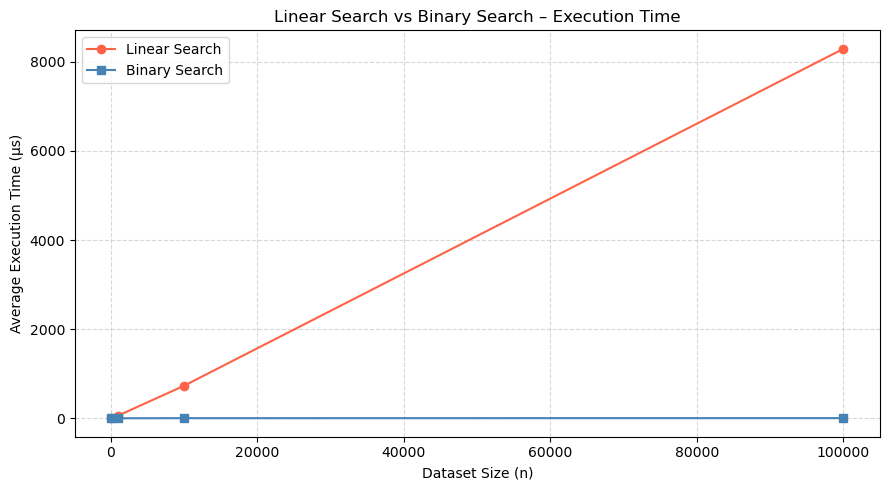

Interpretation:
  Linear Search time grows sharply as n increases.
  Binary Search stays nearly flat because it uses log(n) steps.
  For large product databases, Binary Search is clearly the better choice.


In [8]:
import matplotlib.pyplot as plt

sizes_p  = [r[0] for r in results]
linear_t = [r[1] for r in results]
binary_t = [r[2] for r in results]

plt.figure(figsize=(9, 5))
plt.plot(sizes_p, linear_t, marker="o", label="Linear Search", color="tomato")
plt.plot(sizes_p, binary_t, marker="s", label="Binary Search", color="steelblue")
plt.xlabel("Dataset Size (n)")
plt.ylabel("Average Execution Time (µs)")
plt.title("Linear Search vs Binary Search – Execution Time")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  Linear Search time grows sharply as n increases.")
print("  Binary Search stays nearly flat because it uses log(n) steps.")
print("  For large product databases, Binary Search is clearly the better choice.")

---
<a id='q5'></a>
# Question 5 – Delivery Route Optimisation (East Africa Logistics)

We compare three algorithmic paradigms for optimising delivery routes.

## (a) Greedy Algorithm – Nearest Delivery Destination

In [9]:
import math

destinations = {
    "Kigali":        (-1.9441, 30.0619),
    "Kampala":       (0.3476,  32.5825),
    "Nairobi":       (-1.2921, 36.8219),
    "Dar es Salaam": (-6.7924, 39.2083),
    "Mombasa":       (-4.0435, 39.6682),
}

def euclidean_distance(a, b):
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

def greedy_route(locations, start):
    """Always move to the closest unvisited city next."""
    unvisited  = dict(locations)
    current    = start
    route      = [current]
    total_dist = 0
    del unvisited[current]

    while unvisited:
        nearest = min(unvisited, key=lambda c: euclidean_distance(locations[current], locations[c]))
        total_dist += euclidean_distance(locations[current], locations[nearest])
        route.append(nearest)
        current = nearest
        del unvisited[current]

    return route, round(total_dist, 4)

route, dist = greedy_route(destinations, "Kigali")
print("Greedy Route (Nearest Neighbour):")
print("  " + " → ".join(route))
print(f"  Total distance (degree units): {dist}")

Greedy Route (Nearest Neighbour):
  Kigali → Kampala → Nairobi → Mombasa → Dar es Salaam
  Total distance (degree units): 14.698


## (b) Dynamic Programming – Minimise Transportation Costs (Floyd-Warshall)

In [10]:
cities = ["Kigali", "Kampala", "Nairobi", "Mombasa"]

# Transport cost matrix (RWF thousands). 0 = same city.
cost = [
    [0,   120, 250, 400],
    [120,   0, 180, 350],
    [250, 180,   0, 100],
    [400, 350, 100,   0],
]

def floyd_warshall(cost):
    """Find the cheapest route between every pair of cities."""
    n    = len(cost)
    dist = [row[:] for row in cost]

    for k in range(n):
        for i in range(n):
            for j in range(n):
                if dist[i][k] + dist[k][j] < dist[i][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]
    return dist

cheapest = floyd_warshall(cost)

print("Minimum Transport Costs (RWF thousands)")
print("=" * 50)
header = f"{'':14}" + "".join(f"{c:14}" for c in cities)
print(header)
print("-" * len(header))
for i, row in enumerate(cheapest):
    print(f"{cities[i]:14}" + "".join(f"{v:14}" for v in row))

Minimum Transport Costs (RWF thousands)
              Kigali        Kampala       Nairobi       Mombasa       
----------------------------------------------------------------------
Kigali                     0           120           250           350
Kampala                  120             0           180           280
Nairobi                  250           180             0           100
Mombasa                  350           280           100             0


## (c) Backtracking – All Valid Routes Under a Cost Constraint

In [11]:
MAX_COST   = 700   # RWF thousands
all_routes = []

def backtrack(current, visited, path, current_cost):
    if len(path) == len(cities):
        all_routes.append((path[:], current_cost))
        return
    for next_city in range(len(cities)):
        if next_city not in visited:
            new_cost = current_cost + cost[current][next_city]
            if new_cost <= MAX_COST:
                visited.add(next_city)
                path.append(cities[next_city])
                backtrack(next_city, visited, path, new_cost)
                path.pop()
                visited.remove(next_city)

all_routes.clear()
backtrack(0, {0}, [cities[0]], 0)

print(f"Valid routes from Kigali (cost ≤ {MAX_COST}k RWF):")
for route, total in sorted(all_routes, key=lambda x: x[1]):
    print(f"  {' → '.join(route)}  |  {total}k RWF")

Valid routes from Kigali (cost ≤ 700k RWF):
  Kigali → Kampala → Nairobi → Mombasa  |  400k RWF
  Kigali → Kampala → Mombasa → Nairobi  |  570k RWF
  Kigali → Mombasa → Nairobi → Kampala  |  680k RWF
  Kigali → Nairobi → Mombasa → Kampala  |  700k RWF


## (d) Performance Comparison

In [12]:
import time

def time_ms(func):
    start = time.perf_counter()
    func()
    return (time.perf_counter() - start) * 1000

t_g = time_ms(lambda: greedy_route(destinations, "Kigali"))
t_d = time_ms(lambda: floyd_warshall(cost))
all_routes.clear()
t_b = time_ms(lambda: backtrack(0, {0}, [cities[0]], 0))

print(f"{'Algorithm':<25} {'Time (ms)':>12}  Notes")
print("-" * 65)
print(f"{'Greedy (nearest)':<25} {t_g:>12.4f}  Fast, not always optimal")
print(f"{'Dynamic Programming':<25} {t_d:>12.4f}  Optimal cost, all pairs")
print(f"{'Backtracking':<25} {t_b:>12.4f}  Finds all valid routes, slow on large graphs")

Algorithm                    Time (ms)  Notes
-----------------------------------------------------------------
Greedy (nearest)                0.0523  Fast, not always optimal
Dynamic Programming             0.0266  Optimal cost, all pairs
Backtracking                    0.0320  Finds all valid routes, slow on large graphs


---
<a id='q6'></a>
# Question 6 – Intelligent Road Navigation System

We model cities as nodes and roads as weighted edges, then find shortest paths and minimum spanning trees.

## (a) Weighted Graph Using Adjacency List

In [13]:
# city → list of (neighbour, distance_km)
road_graph = {
    "Kigali":  [("Huye", 120),   ("Musanze", 100), ("Kayonza", 90)],
    "Huye":    [("Kigali", 120), ("Rusizi", 60)],
    "Musanze": [("Kigali", 100), ("Rubavu", 55),   ("Kayonza", 170)],
    "Kayonza": [("Kigali", 90),  ("Musanze", 170), ("Kirehe", 80)],
    "Rubavu":  [("Musanze", 55), ("Rusizi", 230)],
    "Rusizi":  [("Huye", 60),    ("Rubavu", 230)],
    "Kirehe":  [("Kayonza", 80)],
}

print("Road Network (Adjacency List)")
print("=" * 50)
for city, roads in road_graph.items():
    conn = ", ".join(f"{nb} ({d} km)" for nb, d in roads)
    print(f"  {city:10} → {conn}")

Road Network (Adjacency List)
  Kigali     → Huye (120 km), Musanze (100 km), Kayonza (90 km)
  Huye       → Kigali (120 km), Rusizi (60 km)
  Musanze    → Kigali (100 km), Rubavu (55 km), Kayonza (170 km)
  Kayonza    → Kigali (90 km), Musanze (170 km), Kirehe (80 km)
  Rubavu     → Musanze (55 km), Rusizi (230 km)
  Rusizi     → Huye (60 km), Rubavu (230 km)
  Kirehe     → Kayonza (80 km)


## (b) Dijkstra's Algorithm – Shortest Route

In [14]:
import heapq

def dijkstra(graph, source):
    dist     = {city: float('inf') for city in graph}
    previous = {city: None for city in graph}
    dist[source] = 0
    heap = [(0, source)]

    while heap:
        d, city = heapq.heappop(heap)
        if d > dist[city]:
            continue
        for neighbour, weight in graph[city]:
            new_d = dist[city] + weight
            if new_d < dist[neighbour]:
                dist[neighbour] = new_d
                previous[neighbour] = city
                heapq.heappush(heap, (new_d, neighbour))

    return dist, previous

def get_path(previous, target):
    path = []
    while target:
        path.append(target)
        target = previous[target]
    return list(reversed(path))

distances, previous = dijkstra(road_graph, "Kigali")
print("Shortest distances from Kigali")
print("-" * 45)
for city, d in distances.items():
    path = " → ".join(get_path(previous, city))
    print(f"  {city:10} : {d:4} km  |  {path}")

Shortest distances from Kigali
---------------------------------------------
  Kigali     :    0 km  |  Kigali
  Huye       :  120 km  |  Kigali → Huye
  Musanze    :  100 km  |  Kigali → Musanze
  Kayonza    :   90 km  |  Kigali → Kayonza
  Rubavu     :  155 km  |  Kigali → Musanze → Rubavu
  Rusizi     :  180 km  |  Kigali → Huye → Rusizi
  Kirehe     :  170 km  |  Kigali → Kayonza → Kirehe


## (c) BFS and DFS Traversal

In [15]:
from collections import deque

simple = {c: [nb for nb, _ in neighbours] for c, neighbours in road_graph.items()}

def bfs_roads(graph, start):
    visited, queue, seen = [], deque([start]), {start}
    while queue:
        city = queue.popleft()
        visited.append(city)
        for nb in sorted(graph.get(city, [])):
            if nb not in seen:
                seen.add(nb); queue.append(nb)
    return visited

def dfs_roads(graph, start, seen=None, visited=None):
    if seen is None:
        seen, visited = set(), []
    seen.add(start); visited.append(start)
    for nb in sorted(graph.get(start, [])):
        if nb not in seen:
            dfs_roads(graph, nb, seen, visited)
    return visited

print("BFS from Kigali:", " → ".join(bfs_roads(simple, "Kigali")))
print("DFS from Kigali:", " → ".join(dfs_roads(simple, "Kigali")))

BFS from Kigali: Kigali → Huye → Kayonza → Musanze → Rusizi → Kirehe → Rubavu
DFS from Kigali: Kigali → Huye → Rusizi → Rubavu → Musanze → Kayonza → Kirehe


## (d) Kruskal's Minimum Spanning Tree

In [16]:
edges = set()
for city, roads in road_graph.items():
    for nb, dist in roads:
        edges.add(tuple(sorted([city, nb])) + (dist,))
edges = sorted(edges, key=lambda e: e[2])

parent = {}
def find(x):
    while parent.get(x, x) != x:
        x = parent[x]
    return x
def union(x, y):
    parent[find(x)] = find(y)

mst, total = [], 0
for a, b, d in edges:
    if find(a) != find(b):
        union(a, b); mst.append((a, b, d)); total += d

print("Kruskal's Minimum Spanning Tree")
print("=" * 45)
for a, b, d in mst:
    print(f"  {a} ↔ {b}  :  {d} km")
print(f"\n  Total MST length: {total} km")
print()
print("Importance in infrastructure planning:")
print("  The MST connects all cities with the minimum total road length,")
print("  saving construction and maintenance costs while keeping every")
print("  city reachable from every other.")

Kruskal's Minimum Spanning Tree
  Musanze ↔ Rubavu  :  55 km
  Huye ↔ Rusizi  :  60 km
  Kayonza ↔ Kirehe  :  80 km
  Kayonza ↔ Kigali  :  90 km
  Kigali ↔ Musanze  :  100 km
  Huye ↔ Kigali  :  120 km

  Total MST length: 505 km

Importance in infrastructure planning:
  The MST connects all cities with the minimum total road length,
  saving construction and maintenance costs while keeping every
  city reachable from every other.


---
<a id='q7'></a>
# Question 7 – Student Performance Analytics System

We implement and compare **Bubble Sort** and **Merge Sort** for sorting exam scores.

## (a) Bubble Sort and Merge Sort

In [17]:
def bubble_sort(arr):
    """Repeatedly swap adjacent elements if they are in the wrong order."""
    arr = arr[:]
    n   = len(arr)
    for i in range(n - 1):
        swapped = False
        for j in range(n - 1 - i):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swapped = True
        if not swapped:
            break   # already sorted
    return arr

def merge_sort(arr):
    """Divide list in half, sort each half, then merge them back together."""
    if len(arr) <= 1:
        return arr
    mid   = len(arr) // 2
    left  = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    result, i, j = [], 0, 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i]); i += 1
        else:
            result.append(right[j]); j += 1
    result.extend(left[i:]); result.extend(right[j:])
    return result

scores = [72, 45, 90, 60, 38, 85, 55, 78, 92, 67]
print("Original scores   :", scores)
print("Bubble Sort result:", bubble_sort(scores))
print("Merge Sort result :", merge_sort(scores))
print("Top 3 students    :", merge_sort(scores)[-3:][::-1])

Original scores   : [72, 45, 90, 60, 38, 85, 55, 78, 92, 67]
Bubble Sort result: [38, 45, 55, 60, 67, 72, 78, 85, 90, 92]
Merge Sort result : [38, 45, 55, 60, 67, 72, 78, 85, 90, 92]
Top 3 students    : [92, 90, 85]


## (b) Time Complexity Comparison

| Algorithm   | Best Case  | Average Case | Worst Case | Space |
|-------------|------------|--------------|------------|-------|
| Bubble Sort | O(n)       | O(n²)        | O(n²)      | O(1)  |
| Merge Sort  | O(n log n) | O(n log n)   | O(n log n) | O(n)  |

Bubble Sort is simple but very slow for large lists.  
Merge Sort is always O(n log n) — far faster for big datasets, using some extra memory.

## (c) Benchmark Execution Time

In [ ]:
import time, random

def benchmark(sort_fn, data):
    arr   = data[:]
    start = time.perf_counter()
    sort_fn(arr)
    return (time.perf_counter() - start) * 1000   # ms

sizes = [100, 500, 1000, 5000, 10000]
bub_times, mrg_times = [], []

print(f"{'Size':>8}  {'Bubble (ms)':>14}  {'Merge (ms)':>12}")
print("-" * 40)
for n in sizes:
    data = [random.randint(0, 1000) for _ in range(n)]
    bt   = benchmark(bubble_sort, data)
    mt   = benchmark(merge_sort,  data)
    bub_times.append(bt); mrg_times.append(mt)
    print(f"{n:>8}  {bt:>14.2f}  {mt:>12.4f}")

    Size     Bubble (ms)    Merge (ms)
----------------------------------------
     100            0.95        0.2898
     500           30.94        3.9931
    1000          129.11        5.7082
    5000         3956.00       34.2088


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(sizes, bub_times, marker="o", label="Bubble Sort", color="tomato")
plt.plot(sizes, mrg_times, marker="s", label="Merge Sort",  color="steelblue")
plt.xlabel("Number of Students (n)")
plt.ylabel("Execution Time (ms)")
plt.title("Bubble Sort vs Merge Sort – Execution Time")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

## (d) Recommendation

**Merge Sort** is the best choice for a large university exam system because:
- Its O(n log n) time stays fast even with 100,000+ student records.
- Bubble Sort's O(n²) becomes extremely slow beyond a few thousand records.
- The extra O(n) memory Merge Sort uses is acceptable on modern computers.

Bubble Sort is fine only for very small datasets (fewer than ~1,000 records) where its simplicity makes it easy to understand and debug.

---
<a id='q8'></a>
# Question 8 – Hospital Patient Queue Management System

Patients in an emergency department are served in order of medical urgency.

## (a) Role of Queue Data Structures in Healthcare

A **queue** is a First-In, First-Out (FIFO) structure — the first person to arrive is the first to be served.

In healthcare queues are essential because:
1. **Orderly service** – Patients are treated in a fair, predictable order.
2. **Priority queues** – Critical patients (heart attack, trauma) jump ahead regardless of arrival time.
3. **Resource allocation** – Queues model beds, doctors, and theatres so they are never double-booked.
4. **Reduced wait times** – Queue analytics help managers add staff during peak hours.
5. **Audit trail** – Every patient's arrival, priority level, and treatment time is logged automatically.

## (b) Basic Patient Queue Using Python

In [1]:
from collections import deque

class PatientQueue:
    """Simple FIFO queue for patient registration."""
    def __init__(self):
        self._queue = deque()

    def enqueue(self, patient):
        self._queue.append(patient)
        print(f"  Registered : {patient}")

    def dequeue(self):
        if not self._queue:
            print("  Queue is empty.")
            return None
        patient = self._queue.popleft()
        print(f"  Now serving: {patient}")
        return patient

    def display(self):
        print("  Current queue:", list(self._queue) if self._queue else "Empty")

print("=== Patient Registration Queue ===")
q = PatientQueue()
q.enqueue("Jean Mugisha")
q.enqueue("Diane Iradukunda")
q.enqueue("Eric Nkurunziza")
q.display()
print()
q.dequeue()
q.display()

=== Patient Registration Queue ===
  Registered : Jean Mugisha
  Registered : Diane Iradukunda
  Registered : Eric Nkurunziza
  Current queue: ['Jean Mugisha', 'Diane Iradukunda', 'Eric Nkurunziza']

  Now serving: Jean Mugisha
  Current queue: ['Diane Iradukunda', 'Eric Nkurunziza']


## (c) Priority Queue for Emergency Patients

In [2]:
import heapq

PRIORITY = {"Critical": 1, "Urgent": 2, "Semi-urgent": 3, "Non-urgent": 4}

class EmergencyQueue:
    """Priority queue — most critical patient is always treated first."""
    def __init__(self):
        self._heap    = []
        self._counter = 0   # tie-breaker: earlier arrivals first

    def admit(self, name, urgency):
        priority = PRIORITY.get(urgency, 5)
        heapq.heappush(self._heap, (priority, self._counter, name, urgency))
        self._counter += 1
        print(f"  Admitted : {name:22s} [{urgency}]")

    def treat_next(self):
        if not self._heap:
            print("  No patients waiting."); return
        _, _, name, urgency = heapq.heappop(self._heap)
        print(f"  TREATING : {name:22s} [{urgency}]")

    def display(self):
        if not self._heap:
            print("  Queue is empty."); return
        print("  Waiting (by priority):")
        for p, _, name, urg in sorted(self._heap):
            print(f"    Priority {p}: {name} [{urg}]")

print("=== Emergency Department Queue ===")
eq = EmergencyQueue()
eq.admit("Alice Uwase",     "Non-urgent")
eq.admit("Bob Habimana",    "Critical")
eq.admit("Carol Mukamana",  "Urgent")
eq.admit("David Niyonzima", "Semi-urgent")
eq.admit("Eve Ingabire",    "Critical")
print()
eq.display()
print()
print("Treating patients in priority order:")
for _ in range(5):
    eq.treat_next()

=== Emergency Department Queue ===
  Admitted : Alice Uwase            [Non-urgent]
  Admitted : Bob Habimana           [Critical]
  Admitted : Carol Mukamana         [Urgent]
  Admitted : David Niyonzima        [Semi-urgent]
  Admitted : Eve Ingabire           [Critical]

  Waiting (by priority):
    Priority 1: Bob Habimana [Critical]
    Priority 1: Eve Ingabire [Critical]
    Priority 2: Carol Mukamana [Urgent]
    Priority 3: David Niyonzima [Semi-urgent]
    Priority 4: Alice Uwase [Non-urgent]

Treating patients in priority order:
  TREATING : Bob Habimana           [Critical]
  TREATING : Eve Ingabire           [Critical]
  TREATING : Carol Mukamana         [Urgent]
  TREATING : David Niyonzima        [Semi-urgent]
  TREATING : Alice Uwase            [Non-urgent]


## (d) Efficiency of Queue Operations

| Operation | Basic Queue | Priority Queue |
|-----------|-------------|----------------|
| Enqueue   | O(1)        | O(log n)       |
| Dequeue   | O(1)        | O(log n)       |
| Peek      | O(1)        | O(1)           |

- The **basic queue** is O(1) for all operations — ideal for registration desks.
- The **priority queue** uses a binary heap, giving O(log n) insert and remove — still very fast even with hundreds of waiting patients.
- Using a priority queue ensures a critical patient admitted fifth is treated before a non-urgent patient admitted first, which can save lives.

---
<a id='q9'></a>
# Question 9 – Student Records with Hashing

An online learning platform uses hash tables to store and retrieve thousands of student records efficiently.

## (a) What is Hashing?

**Hashing** converts a key (e.g. a student ID) into a table index using a **hash function**.  
A **hash table** stores key-value pairs at the positions produced by this function.

**Why it is useful:**
- Retrieval is **O(1) on average** — no matter how many records exist, finding one takes roughly the same time.
- Much faster than a sorted list (O(log n)) or an unsorted list (O(n)).

**Collision** — When two different keys produce the same index, called a *collision* (see part d for how to handle it).

## (b & c) Hash Table — Insert, Search, Update, Delete

In [3]:
class StudentHashTable:
    """Hash table backed by a Python dictionary (open addressing handled internally)."""

    def __init__(self):
        self._table = {}

    def insert(self, student_id, record):
        """Add a new student record."""
        if student_id in self._table:
            print(f"  [!] ID {student_id} already exists. Use update() to change it.")
            return
        self._table[student_id] = record
        print(f"  Inserted : {student_id} → {record['name']}")

    def search(self, student_id):
        """Find and return a student record."""
        record = self._table.get(student_id)
        if record:
            print(f"  Found    : {student_id} → {record}")
        else:
            print(f"  Not found: {student_id}")
        return record

    def update(self, student_id, new_data):
        """Update one or more fields of an existing record."""
        if student_id not in self._table:
            print(f"  [!] Cannot update: {student_id} does not exist.")
            return
        self._table[student_id].update(new_data)
        print(f"  Updated  : {student_id} → {self._table[student_id]}")

    def delete(self, student_id):
        """Remove a student record."""
        if student_id in self._table:
            name = self._table.pop(student_id)['name']
            print(f"  Deleted  : {student_id} ({name})")
        else:
            print(f"  [!] Cannot delete: {student_id} not found.")

    def display_all(self):
        print("  All student records:")
        for sid, rec in self._table.items():
            print(f"    {sid}: {rec}")

db = StudentHashTable()

print("── INSERT ──────────────────────────────")
db.insert("STU001", {"name": "Alice Uwase",    "course": "CS",   "grade": "A"})
db.insert("STU002", {"name": "Bob Habimana",   "course": "IT",   "grade": "B"})
db.insert("STU003", {"name": "Carol Mukamana", "course": "CS",   "grade": "A+"})
db.insert("STU001", {"name": "Duplicate test"})   # should warn

print()
print("── SEARCH ──────────────────────────────")
db.search("STU002")
db.search("STU999")   # not found

print()
print("── UPDATE ──────────────────────────────")
db.update("STU002", {"grade": "A", "course": "Data Science"})

print()
print("── DELETE ──────────────────────────────")
db.delete("STU003")

print()
print("── FINAL TABLE ─────────────────────────")
db.display_all()

── INSERT ──────────────────────────────
  Inserted : STU001 → Alice Uwase
  Inserted : STU002 → Bob Habimana
  Inserted : STU003 → Carol Mukamana
  [!] ID STU001 already exists. Use update() to change it.

── SEARCH ──────────────────────────────
  Found    : STU002 → {'name': 'Bob Habimana', 'course': 'IT', 'grade': 'B'}
  Not found: STU999

── UPDATE ──────────────────────────────
  Updated  : STU002 → {'name': 'Bob Habimana', 'course': 'Data Science', 'grade': 'A'}

── DELETE ──────────────────────────────
  Deleted  : STU003 (Carol Mukamana)

── FINAL TABLE ─────────────────────────
  All student records:
    STU001: {'name': 'Alice Uwase', 'course': 'CS', 'grade': 'A'}
    STU002: {'name': 'Bob Habimana', 'course': 'Data Science', 'grade': 'A'}


## (d) Collision Resolution Techniques

A **collision** occurs when two different keys hash to the same index.

### 1. Chaining (Separate Chaining)
Each slot holds a linked list. Colliding keys share the same list.  
- ✅ Simple; table never "fills up".  
- ❌ Extra memory; worst case O(n) if all keys land in one slot.

### 2. Linear Probing (Open Addressing)
If a slot is taken, try the next slot (slot + 1, slot + 2, …).  
- ✅ No extra structures.  
- ❌ Clusters of occupied slots form, slowing future lookups.

### 3. Quadratic Probing
Jump by 1², 2², 3², … to reduce clustering compared to linear probing.

### 4. Double Hashing
A second hash function determines the jump size, spreading keys more evenly.

**Why it matters in database systems:**  
Databases store millions of records. A good collision strategy keeps average lookup time at O(1) even under heavy load, keeping the system fast and reliable.

---
<a id='q10'></a>
# Question 10 – Recursion & Divide-and-Conquer in Recommendation Engines

We explore recursion and divide-and-conquer strategies applied to product recommendation scoring.

## (a) Recursion and Divide-and-Conquer Explained

### Recursion
A function is *recursive* when it calls **itself** to solve a smaller version of the same problem.  
Every recursive function needs:
1. **Base case** – The simplest form of the problem solved directly (stops infinite looping).
2. **Recursive case** – Breaks the problem into a smaller piece and calls itself again.

### Divide and Conquer
A three-step design strategy:
1. **Divide** – Split the problem into smaller sub-problems.
2. **Conquer** – Solve each sub-problem recursively.
3. **Combine** – Merge all results into the final answer.

Classic examples: Merge Sort, Binary Search, Quick Sort.

## (b) Recursive Recommendation Score & Loyalty Points

In [ ]:
import math

def recommendation_score(purchase_history, index=0):
    """
    Recursively calculate a total recommendation score.
    Each purchase contributes log2(quantity + 1) × 10 points.
    Base case: all purchases have been processed.
    """
    if index == len(purchase_history):
        return 0   # base case

    product, quantity = purchase_history[index]
    item_score = math.log2(quantity + 1) * 10

    # Recursive case: this item's score + score of all remaining items
    return item_score + recommendation_score(purchase_history, index + 1)


def loyalty_points(total_spending, threshold=10_000, points_per_block=100):
    """
    Recursively award loyalty points: 100 points per RWF 10,000 spent.
    Base case: spending is below the threshold.
    """
    if total_spending < threshold:
        return 0   # base case
    return points_per_block + loyalty_points(total_spending - threshold)


# ── Demo ──────────────────────────────────────────────────────────────────
purchases = [
    ("Rice 5 kg",    3),
    ("Cooking Oil",  2),
    ("Sugar 2 kg",   5),
    ("Biscuits",     1),
    ("Maize Flour",  4),
]

score   = recommendation_score(purchases)
points  = loyalty_points(45_000)

print(f"Recommendation Score : {score:.2f} points")
print(f"Loyalty Points (RWF 45,000 spent): {points} points")

## (c) Time and Space Complexity

| Function               | Time Complexity | Space Complexity |
|------------------------|-----------------|------------------|
| `recommendation_score` | O(n)            | O(n) call stack  |
| `loyalty_points`       | O(s / T)        | O(s / T) stack   |

Where **n** = number of purchases, **s** = total spending, **T** = threshold.

- Both functions make one recursive call per step, so time is linear.
- Each call adds a **stack frame**, so space equals the depth of recursion.
- For very large inputs, convert to an iterative approach or use Python's `sys.setrecursionlimit` to avoid a *stack overflow*.

## (d) Recursive Algorithms in AI and Modern Systems

### Recommendation Systems
Collaborative filtering splits users into groups (divide), computes similarity scores for each group (conquer), then combines rankings (combine). Decision trees in recommendation engines also split data recursively at each node.

### Search Engines
Web crawlers use recursive DFS/BFS to follow links page by page, building an index of the internet.  
PageRank computes authority scores by recursively spreading importance across linked pages.

### Artificial Intelligence
- **Game AI** (chess, Go): Minimax explores all future moves recursively to choose the best one.
- **Decision trees & random forests**: Data is split recursively at each node until a pure result is reached.

### Machine Learning
- **Backpropagation** in neural networks propagates errors backward through layers in a recursive-like manner.
- **Hierarchical clustering** merges or splits data clusters recursively.

In summary, recursion and divide-and-conquer are fundamental to both classical algorithms and modern AI — they make complex problems manageable by breaking them into smaller, solvable pieces.